In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
final_df = pd.read_parquet(r"C:\Users\super\Desktop\Data Thesis\final_df.parquet")

In [3]:
gaze_cols  = [c for c in final_df.columns if "gaze" in c]
pose_cols  = [c for c in final_df.columns if "pose" in c]
au_r_cols  = [c for c in final_df.columns if c.startswith("AU") and c.endswith("_r")]
au_c_cols  = [c for c in final_df.columns if c.startswith("AU") and c.endswith("_c")]

In [4]:
OUTLIER_ID = "7_person8" # removed for unreliable data, participants total 102 same way as CMOSE paper.

print("── Outlier pose stats ──────────────────────────────")
print(final_df[final_df["participant_id"] == OUTLIER_ID][pose_cols].describe().round(2))

print("\n── All other participants pose stats ───────────────")
print(final_df[final_df["participant_id"] != OUTLIER_ID][pose_cols].describe().round(2))

before_frames        = len(final_df)
before_participants  = final_df["participant_id"].nunique()

final_df = final_df[final_df["participant_id"] != OUTLIER_ID].reset_index(drop=True)

print(f"\n── Removal summary ─────────────────────────────────")
print(f"Participants before: {before_participants} → after: {final_df['participant_id'].nunique()}")
print(f"Timesteps before:    {before_frames:,} → after: {len(final_df):,}")
print(f"Timesteps removed:   {before_frames - len(final_df):,}")

── Outlier pose stats ──────────────────────────────
       pose_Tx  pose_Ty  pose_Tz  pose_Rx  pose_Ry  pose_Rz
count  2392.00  2392.00  2392.00  2392.00  2392.00  2392.00
mean     20.27    62.24   442.79    -0.15     0.09    -0.03
std      27.03    19.67    40.87     0.14     0.10     0.09
min    -113.88     3.50   353.86    -0.64    -0.60    -0.63
25%       6.96    51.49   428.05    -0.20     0.04    -0.06
50%      22.83    58.44   440.12    -0.16     0.09    -0.03
75%      36.76    67.12   457.30    -0.03     0.13     0.01
max     106.66   209.32   925.18     0.31     0.48     0.34

── All other participants pose stats ───────────────
            pose_Tx       pose_Ty       pose_Tz    pose_Rx    pose_Ry  \
count  8.301950e+05  8.301950e+05  8.301950e+05  830195.00  830195.00   
mean  -6.434953e+04 -4.142770e+04  1.678389e+05       0.04       0.05   
std    2.112933e+07  7.045227e+06  4.360396e+07       0.19       0.19   
min   -3.086994e+07 -1.743699e+07 -4.154200e+02      -3.12   

In [5]:
before_frames = len(final_df)

print("── Failed tracking summary ─────────────────────────")
print(f"Success=0 frames: {(final_df['success'] == 0).sum():,} ({(final_df['success'] == 0).mean():.2%})")
print(f"Success=1 frames: {(final_df['success'] == 1).sum():,} ({(final_df['success'] == 1).mean():.2%})")

print("\nFailed tracking by participant (top 10):")
failed_by_participant = (
    final_df[final_df["success"] == 0]
    .groupby("participant_id")
    .size()
    .div(final_df.groupby("participant_id").size())
    .sort_values(ascending=False)
)
print(failed_by_participant.head(10).round(4))

final_df = final_df[final_df["success"] == 1].reset_index(drop=True)

print(f"\n── Removal summary ─────────────────────────────────")
print(f"Frames before: {before_frames:,}")
print(f"Frames after:  {len(final_df):,}")
print(f"Frames removed: {before_frames - len(final_df):,} ({(before_frames - len(final_df))/before_frames:.2%})")
print(f"Participants remaining: {final_df['participant_id'].nunique()}")

── Failed tracking summary ─────────────────────────
Success=0 frames: 21,855 (2.63%)
Success=1 frames: 798,300 (96.16%)

Failed tracking by participant (top 10):
participant_id
7_person10     0.2781
6_person11     0.2605
10_person28    0.1667
14_person20    0.1593
6_person9      0.1514
10_person20    0.1162
6_person14     0.0991
14_person17    0.0866
6_person15     0.0732
14_person18    0.0684
dtype: float64

── Removal summary ─────────────────────────────────
Frames before: 830,195
Frames after:  798,300
Frames removed: 31,895 (3.84%)
Participants remaining: 102


In [6]:
print("Step 1: Preparing features for clustering...")

cluster_feature_cols = gaze_cols + pose_cols

reliable_df = final_df[final_df["confidence"] >= 0.8]
person_features = reliable_df.groupby("participant_id")[cluster_feature_cols].agg(
    ["mean", "std"]
).reset_index()

person_features.columns = [
    "participant_id" if col[0] == "participant_id"
    else f"{col[0]}_{col[1]}"
    for col in person_features.columns
]

print(f"  Participants for clustering: {len(person_features)}")
print(f"  Features per participant:    {person_features.shape[1] - 1}")

Step 1: Preparing features for clustering...
  Participants for clustering: 102
  Features per participant:    28


In [7]:
print("\nStep 2: Standardizing features...")

feature_cols_cluster = [c for c in person_features.columns
                        if c != "participant_id"]

scaler = StandardScaler()
X = scaler.fit_transform(person_features[feature_cols_cluster].fillna(0))

print(f"  Feature matrix shape: {X.shape}")


Step 2: Standardizing features...
  Feature matrix shape: (102, 28)


In [8]:
pca_pre = PCA(n_components=0.80, random_state=42)
X_reduced = pca_pre.fit_transform(X)

print(f"Reduced from {X.shape[1]} to {X_reduced.shape[1]} components")
print(f"Variance explained: {pca_pre.explained_variance_ratio_.sum():.2%}")

Reduced from 28 to 5 components
Variance explained: 80.41%


In [9]:
for var in [0.80, 0.85, 0.90, 0.95, 0.99]:
    pca_test  = PCA(n_components=var, random_state=42)
    X_test    = pca_test.fit_transform(X)
    km        = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels    = km.fit_predict(X_test)
    sil       = silhouette_score(X_test, labels)
    print(f"  PCA {var:.0%}: {pca_test.n_components_} components, silhouette={sil:.4f}")

  PCA 80%: 5 components, silhouette=0.2544
  PCA 85%: 7 components, silhouette=0.2366
  PCA 90%: 8 components, silhouette=0.2295
  PCA 95%: 11 components, silhouette=0.2187
  PCA 99%: 15 components, silhouette=0.2130



Step 3: Finding optimal number of clusters...
  k=2: inertia=1734.8, silhouette=0.2544
  k=3: inertia=1528.7, silhouette=0.1865
  k=4: inertia=1333.7, silhouette=0.2238
  k=5: inertia=1163.6, silhouette=0.1917
  k=6: inertia=1026.0, silhouette=0.1987
  k=7: inertia=962.2, silhouette=0.1936
  k=8: inertia=883.5, silhouette=0.1811
  k=9: inertia=840.3, silhouette=0.1721
  k=10: inertia=771.2, silhouette=0.1852


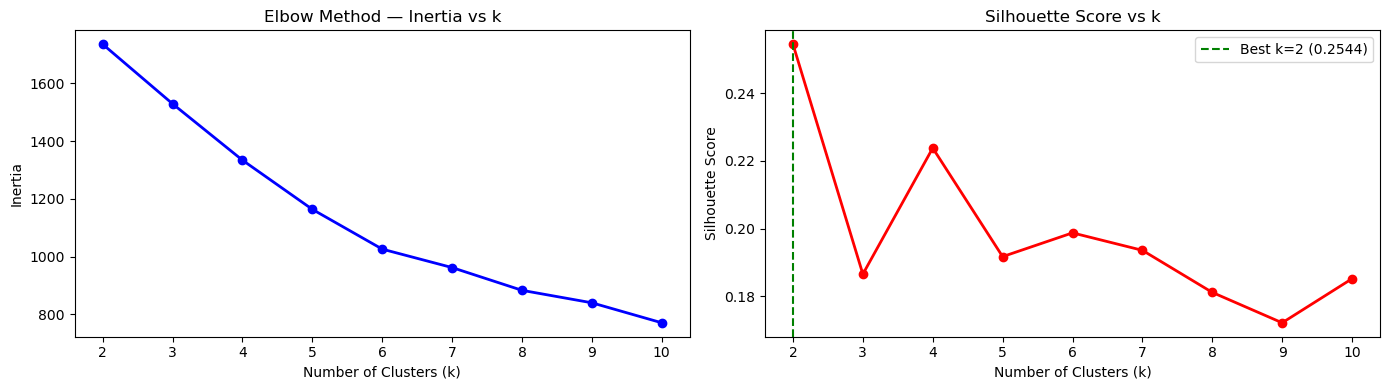


  Best k by silhouette: 2 (score=0.2544)


In [10]:
print("\nStep 3: Finding optimal number of clusters...")

k_range    = range(2, 11)
inertias   = []
sil_scores = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_reduced, labels))
    print(f"  k={k}: inertia={km.inertia_:.1f}, silhouette={sil_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(k_range), inertias, "bo-", linewidth=2)
axes[0].set_title("Elbow Method — Inertia vs k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), sil_scores, "ro-", linewidth=2)
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(k_range))

best_k = list(k_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color="green", linestyle="--",
                label=f"Best k={best_k} ({max(sil_scores):.4f})")
axes[1].legend()

plt.tight_layout()
# plt.savefig("cluster_selection.png", bbox_inches="tight")
plt.show()

print(f"\n  Best k by silhouette: {best_k} (score={max(sil_scores):.4f})")

In [11]:
print(f"\nStep 4: Fitting KMeans with k={best_k}...")

FINAL_K = best_k

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
person_features["behavioral_cluster"] = kmeans.fit_predict(X_reduced)

print(f"  Cluster distribution:")
print(person_features["behavioral_cluster"].value_counts().sort_index())


Step 4: Fitting KMeans with k=2...
  Cluster distribution:
behavioral_cluster
0    35
1    67
Name: count, dtype: int64



Step 5: Bootstrap stability validation...
  Bootstrap silhouette (n=100 successful iterations):
  Mean:   0.2892
  Std:    0.0637
  95% CI: [0.2137, 0.4787]


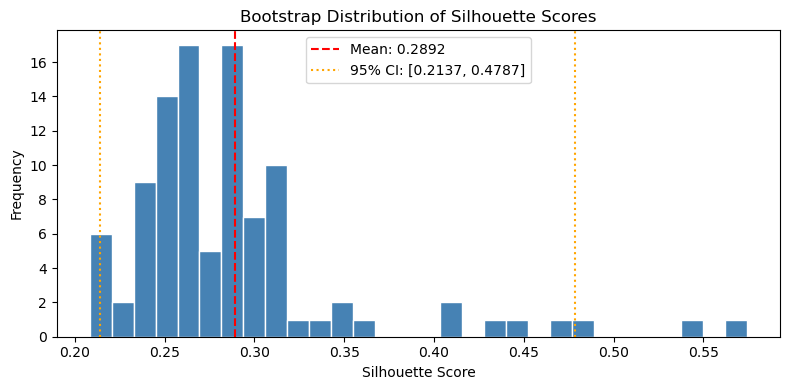

  ✓ Clusters are stable (CI lower bound 0.2137 > 0.2)


In [12]:
print("\nStep 5: Bootstrap stability validation...") # This bootstrap is a different run from the one in the paper

N_BOOTSTRAP   = 100
bootstrap_sil = []

for i in range(N_BOOTSTRAP):
    idx    = np.random.choice(len(X_reduced), size=len(X_reduced), replace=True)
    X_boot = X_reduced[idx]

    km_boot     = KMeans(n_clusters=FINAL_K, random_state=i, n_init=5)
    labels_boot = km_boot.fit_predict(X_boot)

    if len(np.unique(labels_boot)) == FINAL_K:
        sil = silhouette_score(X_boot, labels_boot)
        bootstrap_sil.append(sil)

bootstrap_sil = np.array(bootstrap_sil)

ci_lower = np.percentile(bootstrap_sil, 2.5)
ci_upper = np.percentile(bootstrap_sil, 97.5)

print(f"  Bootstrap silhouette (n={len(bootstrap_sil)} successful iterations):")
print(f"  Mean:   {bootstrap_sil.mean():.4f}")
print(f"  Std:    {bootstrap_sil.std():.4f}")
print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bootstrap_sil, bins=30, color="steelblue", edgecolor="white")
ax.axvline(bootstrap_sil.mean(), color="red", linestyle="--",
           label=f"Mean: {bootstrap_sil.mean():.4f}")
ax.axvline(ci_lower, color="orange", linestyle=":",
           label=f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
ax.axvline(ci_upper, color="orange", linestyle=":")
ax.set_title("Bootstrap Distribution of Silhouette Scores")
ax.set_xlabel("Silhouette Score")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
# plt.savefig("bootstrap_stability.png", bbox_inches="tight")
plt.show()

STABILITY_THRESHOLD = 0.2
if ci_lower > STABILITY_THRESHOLD:
    print(f"  ✓ Clusters are stable (CI lower bound {ci_lower:.4f} > {STABILITY_THRESHOLD})")
else:
    print(f"  ⚠ Clusters may be unstable (CI lower bound {ci_lower:.4f} < {STABILITY_THRESHOLD})")
    print(f"    Consider adjusting k or feature space")


Step 6: Cluster interpretability analysis...

── Mean feature values per cluster ─────
behavioral_cluster        0        1
gaze_0_x_mean         0.083    0.065
gaze_0_x_std          0.122    0.087
gaze_0_y_mean         0.155    0.057
gaze_0_y_std          0.100    0.070
gaze_0_z_mean        -0.960   -0.982
gaze_0_z_std          0.034    0.017
gaze_1_x_mean        -0.093   -0.114
gaze_1_x_std          0.125    0.086
gaze_1_y_mean         0.152    0.058
gaze_1_y_std          0.099    0.070
gaze_1_z_mean        -0.959   -0.977
gaze_1_z_std          0.034    0.019
gaze_angle_x_mean    -0.005   -0.025
gaze_angle_x_std      0.129    0.088
gaze_angle_y_mean     0.158    0.059
gaze_angle_y_std      0.105    0.071
pose_Tx_mean         25.015   23.460
pose_Tx_std          47.449   31.149
pose_Ty_mean         11.926   29.358
pose_Ty_std          31.699   21.880
pose_Tz_mean        528.480  478.325
pose_Tz_std          55.875   39.462
pose_Rx_mean          0.134    0.006
pose_Rx_std           0.

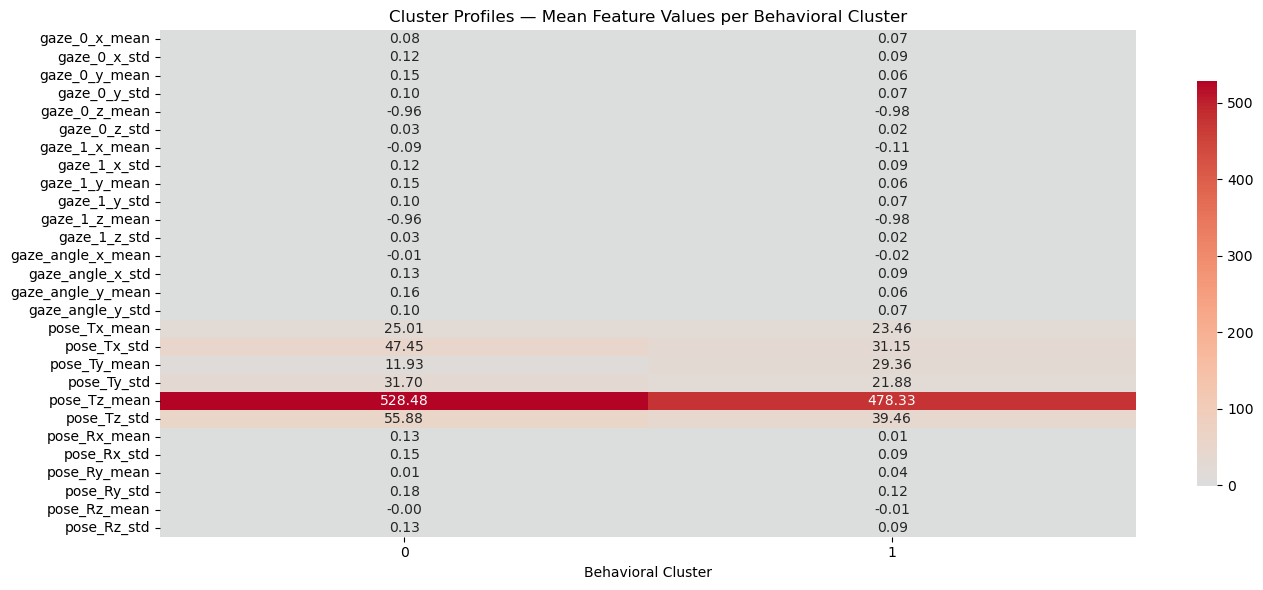

In [13]:
print("\nStep 6: Cluster interpretability analysis...")

cluster_profiles = person_features.groupby("behavioral_cluster")[
    feature_cols_cluster].mean()

print("\n── Mean feature values per cluster ─────")
print(cluster_profiles.round(3).T)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cluster_profiles.T, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Cluster Profiles — Mean Feature Values per Behavioral Cluster")
ax.set_xlabel("Behavioral Cluster")
plt.tight_layout()
# plt.savefig("cluster_profiles.png", bbox_inches="tight")
plt.show()

In [14]:
cluster_profiles = person_features.groupby("behavioral_cluster")[
    feature_cols_cluster].mean()

cluster_diff = cluster_profiles.diff().iloc[-1].abs().sort_values(ascending=False)
print("Top features distinguishing the two clusters:")
print(cluster_diff.head(10).round(4))

Top features distinguishing the two clusters:
pose_Tz_mean         50.1545
pose_Ty_mean         17.4319
pose_Tz_std          16.4133
pose_Tx_std          16.2992
pose_Ty_std           9.8190
pose_Tx_mean          1.5553
pose_Rx_mean          0.1282
gaze_angle_y_mean     0.0993
gaze_0_y_mean         0.0977
gaze_1_y_mean         0.0942
Name: 1, dtype: float64


In [15]:
print("\nStep 8: Assigning cluster labels to final_df...")

final_df = final_df.merge(
    person_features[["participant_id", "behavioral_cluster"]],
    on="participant_id",
    how="left"
)

print(f"  Timesteps per cluster:")
print(final_df["behavioral_cluster"].value_counts().sort_index())

print(f"\n  Engagement rate per cluster:")
print(final_df.groupby("behavioral_cluster")["engagement"].mean().round(3))


Step 8: Assigning cluster labels to final_df...
  Timesteps per cluster:
behavioral_cluster
0    230284
1    568016
Name: count, dtype: int64

  Engagement rate per cluster:
behavioral_cluster
0    0.782
1    0.815
Name: engagement, dtype: float64


In [16]:
print("\n" + "═" * 60)
print("BEHAVIORAL GROUPING SUMMARY")
print("═" * 60)

summary = final_df.groupby("behavioral_cluster").agg(
    n_participants  = ("participant_id", "nunique"),
    n_clips         = ("clip_id", "nunique"),
    n_timesteps     = ("participant_id", "count"),
    engagement_rate = ("engagement", "mean")
).reset_index()

print(summary.round(3).to_string(index=False))
print(f"\nBootstrap silhouette 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Stability: {'✓ Stable' if ci_lower > STABILITY_THRESHOLD else '⚠ Unstable — review k'}")


════════════════════════════════════════════════════════════
BEHAVIORAL GROUPING SUMMARY
════════════════════════════════════════════════════════════
 behavioral_cluster  n_participants  n_clips  n_timesteps  engagement_rate
                  0              35     3512       230284            0.782
                  1              67     8581       568016            0.815

Bootstrap silhouette 95% CI: [0.2137, 0.4787]
Stability: ✓ Stable


In [21]:
output_path = r"C:\Users\super\Desktop\Data Thesis\final_df_clustered.parquet"

# final_df.to_parquet(output_path, index=False)

print(f"Would save to: {output_path}")
print(f"Shape: {final_df.shape}")
print(f"Columns included: {final_df.columns.tolist()}")

# verify_df = pd.read_parquet(output_path)
# print(f"\nVerification load shape: {verify_df.shape}")
# print(f"Cluster distribution:\n{verify_df['behavioral_cluster'].value_counts().sort_index()}")

Would save to: C:\Users\super\Desktop\Data Thesis\final_df_clustered.parquet
Shape: (798300, 722)
Columns included: ['face_id', 'confidence', 'success', 'gaze_0_x', 'gaze_0_y', 'gaze_0_z', 'gaze_1_x', 'gaze_1_y', 'gaze_1_z', 'gaze_angle_x', 'gaze_angle_y', 'eye_lmk_x_0', 'eye_lmk_x_1', 'eye_lmk_x_2', 'eye_lmk_x_3', 'eye_lmk_x_4', 'eye_lmk_x_5', 'eye_lmk_x_6', 'eye_lmk_x_7', 'eye_lmk_x_8', 'eye_lmk_x_9', 'eye_lmk_x_10', 'eye_lmk_x_11', 'eye_lmk_x_12', 'eye_lmk_x_13', 'eye_lmk_x_14', 'eye_lmk_x_15', 'eye_lmk_x_16', 'eye_lmk_x_17', 'eye_lmk_x_18', 'eye_lmk_x_19', 'eye_lmk_x_20', 'eye_lmk_x_21', 'eye_lmk_x_22', 'eye_lmk_x_23', 'eye_lmk_x_24', 'eye_lmk_x_25', 'eye_lmk_x_26', 'eye_lmk_x_27', 'eye_lmk_x_28', 'eye_lmk_x_29', 'eye_lmk_x_30', 'eye_lmk_x_31', 'eye_lmk_x_32', 'eye_lmk_x_33', 'eye_lmk_x_34', 'eye_lmk_x_35', 'eye_lmk_x_36', 'eye_lmk_x_37', 'eye_lmk_x_38', 'eye_lmk_x_39', 'eye_lmk_x_40', 'eye_lmk_x_41', 'eye_lmk_x_42', 'eye_lmk_x_43', 'eye_lmk_x_44', 'eye_lmk_x_45', 'eye_lmk_x_46', '

In [22]:
person_features_path = r"C:\Users\super\Desktop\Data Thesis\person_features_clustered.parquet"

# person_features.to_parquet(person_features_path, index=False)

print(f"Would save person_features to: {person_features_path}")
print(f"Shape: {person_features.shape}")

Would save person_features to: C:\Users\super\Desktop\Data Thesis\person_features_clustered.parquet
Shape: (102, 30)


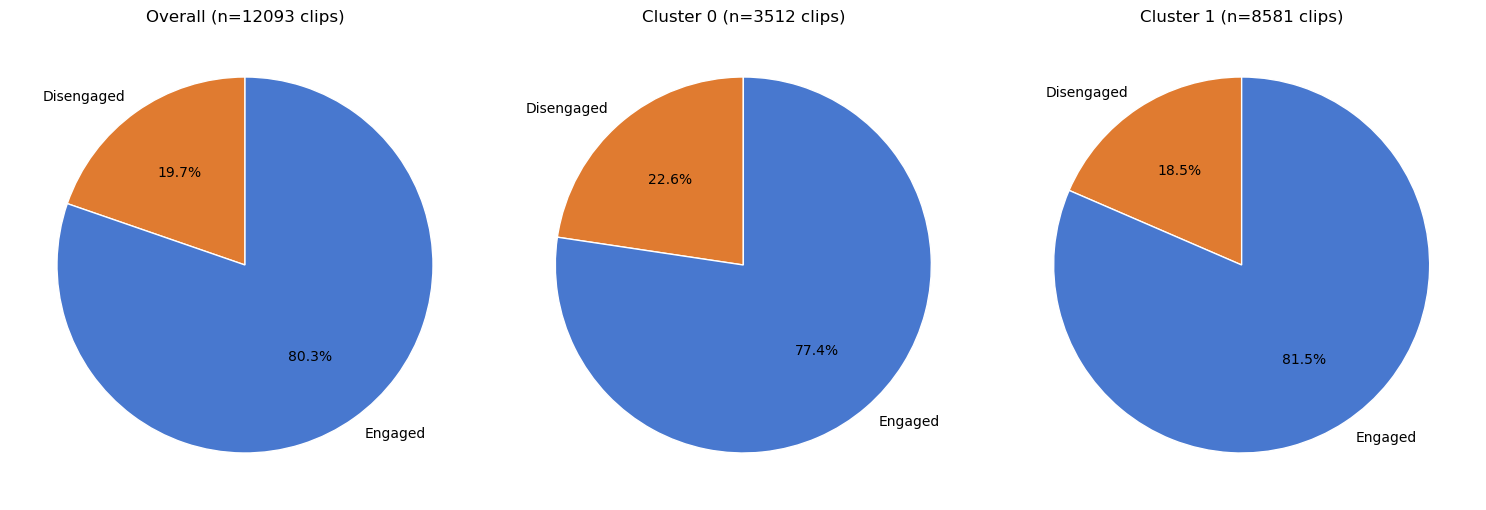

Class balance summary (clip level):
Overall: {'Disengaged': np.int64(2383), 'Engaged': np.int64(9710)}
Cluster 0: {'Disengaged': np.int64(795), 'Engaged': np.int64(2717)}
Cluster 1: {'Disengaged': np.int64(1588), 'Engaged': np.int64(6993)}


In [24]:
clip_level = (
    final_df.groupby("clip_id")
    .agg(engagement=("engagement", "first"),
         behavioral_cluster=("behavioral_cluster", "first"))
    .reset_index()
)

label_names  = {0: "Disengaged", 1: "Engaged"}
label_colors = {0: "#E07B30", 1: "#4878CF"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

overall_counts = clip_level["engagement"].value_counts().sort_index()
axes[0].pie(
    overall_counts.values,
    labels=[label_names[i] for i in overall_counts.index],
    colors=[label_colors[i] for i in overall_counts.index],
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white"}
)
axes[0].set_title(f"Overall (n={len(clip_level)} clips)")

for ax, cluster in zip(axes[1:], sorted(clip_level["behavioral_cluster"].unique())):
    subset = clip_level[clip_level["behavioral_cluster"] == cluster]
    counts = subset["engagement"].value_counts().sort_index()
    ax.pie(
        counts.values,
        labels=[label_names[i] for i in counts.index],
        colors=[label_colors[i] for i in counts.index],
        autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor": "white"}
    )
    ax.set_title(f"Cluster {cluster} (n={len(subset)} clips)")

plt.tight_layout()
plt.savefig("class_balance_by_cluster.pdf", bbox_inches="tight")
plt.show()

print("Class balance summary (clip level):")
print(f"Overall: {dict(overall_counts.rename(index=label_names))}")
for cluster in sorted(clip_level["behavioral_cluster"].unique()):
    subset = clip_level[clip_level["behavioral_cluster"] == cluster]
    counts = subset["engagement"].value_counts().sort_index()
    print(f"Cluster {cluster}: {dict(counts.rename(index=label_names))}")